# Image Filtering: GPU Acceleration in Practice

Image filtering is a fundamental operation in scientific computing, from processing microscopy images in biology to enhancing medical scans. At its core, filtering applies a mathematical operation to each pixel based on its neighbors - a task that's parallel and perfect for GPUs. In this project, we'll use Gaussian blur as our example: smoothing an image by a filter. While simple conceptually (just multiply and sum), processing millions of pixels makes this an ideal candidate for GPU acceleration.

In this notebook, you'll compare three approaches: a CPU baseline using SciPy, GPU acceleration with CuPy (a NumPy-compatible library), and a custom CUDA kernel you'll write yourself using Numba. This progression mirrors real-world GPU development - start with existing libraries for quick wins, then optimize critical sections with custom code when needed.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import time, os
from PIL import Image as PILImage
# Make plots look nice
plt.rcParams['figure.figsize'] = (12, 6)

In [2]:
from google.colab import drive
drive.mount('/content/drive/', force_remount=True)
os.chdir("drive/MyDrive/Image_Filtering_GPU/")

Mounted at /content/drive/


In [3]:
# Download a sample large image from wiki
!wget https://upload.wikimedia.org/wikipedia/commons/8/85/%22_Shot_From_The_Sky%22_Army_Show_1945_Oak_Ridge_%2824971013612%29.jpg -O largeimage.jpg

--2026-02-14 15:33:36--  https://upload.wikimedia.org/wikipedia/commons/8/85/%22_Shot_From_The_Sky%22_Army_Show_1945_Oak_Ridge_%2824971013612%29.jpg
Resolving upload.wikimedia.org (upload.wikimedia.org)... 103.102.166.240, 2001:df2:e500:ed1a::2:b
Connecting to upload.wikimedia.org (upload.wikimedia.org)|103.102.166.240|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 6268505 (6.0M) [image/jpeg]
Saving to: ‘largeimage.jpg’

largeimage.jpg      100%[===================>]   5.98M  6.51MB/s    in 0.9s    

2026-02-14 15:33:38 (6.51 MB/s) - ‘largeimage.jpg’ saved [6268505/6268505]



/usr/local/lib/python3.12/dist-packages/PIL/Image.py:3452: DecompressionBombWarning: Image size (102284000 pixels) exceeds limit of 89478485 pixels, could be decompression bomb DOS attack.
  warnings.warn(


Image shape: (8992, 11375)
Image type: float32
Pixel value range: [0, 255]

This is a 8992x11375 pixel image
Total pixels: 102,284,000


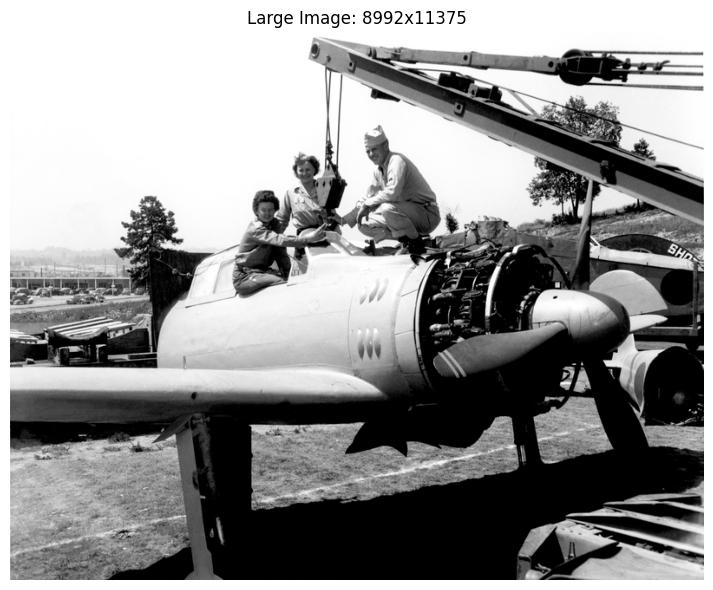

In [4]:
img = PILImage.open('./largeimage.jpg').convert('L')  # 'L' = grayscale
img_array = np.array(img, dtype=np.float32)

print(f"Image shape: {img_array.shape}")
print(f"Image type: {img_array.dtype}")
print(f"Pixel value range: [{img_array.min():.0f}, {img_array.max():.0f}]")
print(f"\nThis is a {img_array.shape[0]}x{img_array.shape[1]} pixel image")
print(f"Total pixels: {img_array.size:,}")

# Visualize
def show_large_image(image_array, max_display_width=800):
    """Display large image at reduced size without modifying original"""
    img_pil = PILImage.fromarray(image_array.astype(np.uint8))

    # Calculate resize ratio
    ratio = max_display_width / image_array.shape[1]
    new_height = int(image_array.shape[0] * ratio)

    # Resize for display
    img_resized = img_pil.resize((max_display_width, new_height), PILImage.Resampling.LANCZOS)

    plt.figure(figsize=(10, 6))
    plt.imshow(img_resized, cmap='gray')
    plt.title(f"Large Image: {image_array.shape[0]}x{image_array.shape[1]}")
    plt.axis('off')
    plt.tight_layout()
    plt.show()

show_large_image(img_array)


## Kernels

In [5]:
# 3x3 Gaussian kernel (smoother)
kernel = np.array([[1, 2, 1],
                   [2, 4, 2],
                   [1, 2, 1]]) / 16
print(kernel.shape[0])

# 5x5 Gaussian kernel (smoother)
kernel = np.array([[1, 4, 6, 4, 1],
                   [4, 16, 24, 16, 4],
                   [6, 24, 36, 24, 6],
                   [4, 16, 24, 16, 4],
                   [1, 4, 6, 4, 1]]) / 256

3


## Blur - CPU vs CuPY vs Custom CUDA Kernel


In [6]:
from scipy.ndimage import gaussian_filter as cpu_gaussian_filter
from numba import cuda
import cupy as cp
from cupyx.scipy import ndimage as cp_ndimage


In [7]:
# CPU version using discrete kernel (for fair comparison with CUDA)
def cpu_blur_discrete_kernel(img_array, kernel):
    """
    CPU blur using the same discrete kernel as CUDA.
    Uses scipy.ndimage.convolve for exact comparison.
    """
    from scipy.ndimage import convolve
    return convolve(img_array, kernel, mode='constant', cval=0.0)


# CuPy version using discrete kernel (for fair comparison with CUDA)
def cupy_blur_discrete_kernel(img_array, kernel):
    """
    GPU blur using the same discrete kernel as CUDA.
    Fair comparison with custom CUDA kernel.
    """
    from cupyx.scipy.ndimage import convolve as cp_convolve
    gpu_image = cp.asarray(img_array)
    gpu_kernel = cp.asarray(kernel)
    blurred_gpu = cp_convolve(gpu_image, gpu_kernel, mode='constant', cval=0.0)
    return cp.asnumpy(blurred_gpu)


In [8]:
@cuda.jit
def gaussian_blur_kernel(image, result, kernel):
    """
    Custom CUDA kernel for Gaussian blur.
    Each thread processes one pixel.
    """
    # Get thread position (which pixel this thread handles)
    i, j = cuda.grid(2)

    # Check bounds
    if i >= image.shape[0] or j >= image.shape[1]:
        return

    # Calculate offset from kernel size
    kernel_size = kernel.shape[0]
    offset = kernel_size // 2

    # Check if pixel is near edge (skip blur for edges)
    if i < offset or i >= image.shape[0] - offset or j < offset or j >= image.shape[1] - offset:
        result[i, j] = image[i, j]
        return

    # Compute weighted average with dynamic kernel size
    weighted_sum = 0.0
    for ki in range(kernel_size):
        for kj in range(kernel_size):
            # Offset to center the kernel around current pixel
            pixel = image[i + ki - offset, j + kj - offset]
            weight = kernel[ki, kj]
            weighted_sum += pixel * weight

    result[i, j] = weighted_sum


def blur_cuda_kernel(image, kernel):
    """
    Apply Gaussian blur using custom CUDA kernel with proper configuration.
    """
    # Copy image and kernel to GPU
    d_image = cuda.to_device(image)
    d_result = cuda.device_array_like(image)  # More efficient allocation
    d_kernel = cuda.to_device(kernel)

    # Configure threads and blocks
    threads_per_block = (16, 16)  # 256 threads per block (standard)
    blocks_x = (image.shape[0] + threads_per_block[0] - 1) // threads_per_block[0]
    blocks_y = (image.shape[1] + threads_per_block[1] - 1) // threads_per_block[1]
    blocks_per_grid = (blocks_x, blocks_y)

    # Launch kernel
    gaussian_blur_kernel[blocks_per_grid, threads_per_block](d_image, d_result, d_kernel)

    # Synchronize to ensure completion
    cuda.synchronize()

    # Copy result back to CPU
    result = d_result.copy_to_host()

    return result


# Test and warmup CUDA
print("Testing CUDA kernel...")
try:
    test_img = np.ones((100, 100), dtype=np.float32)
    test_kernel = np.ones((3, 3), dtype=np.float32) / 9

    # Warmup GPU (first call is slow)
    _ = blur_cuda_kernel(test_img, test_kernel)

    CUDA_AVAILABLE = True
    print("Custom CUDA kernel ready!")
    print(f"  GPU Device: {cuda.get_current_device().name.decode()}")
except Exception as e:
    CUDA_AVAILABLE = False
    print(f"✗ CUDA not available: {e}")

Testing CUDA kernel...


/usr/local/lib/python3.12/dist-packages/numba_cuda/numba/cuda/dispatcher.py:697: NumbaPerformanceWarning: Grid size 49 will likely result in GPU under-utilization due to low occupancy.
  warn(NumbaPerformanceWarning(msg))


Custom CUDA kernel ready!
  GPU Device: Tesla T4


In [9]:
def benchmark_blur():
    """
    Compare CPU vs CuPy vs Custom CUDA Kernel
    NOW WITH FAIR COMPARISON - All use the same discrete kernel!
    """

    print("\n" + "="*70)
    print("BENCHMARK: Fair Comparison Using Same Discrete Kernel")
    print("="*70)
    print(f"\nImage size: {img_array.shape[0]}x{img_array.shape[1]} = {img_array.size:,} pixels")
    print(f"Kernel size: {kernel.shape[0]}x{kernel.shape[1]} Gaussian")

    # ===== 1. CPU (Discrete Kernel) =====
    print("\n CPU (SciPy convolve with discrete kernel)...")
    start = time.time()
    blurred_cpu = cpu_blur_discrete_kernel(img_array, kernel)
    cpu_time = time.time() - start
    print(f"   Time: {cpu_time:.4f}s")

    # ===== 2. GPU CuPy (Discrete Kernel) =====
    print("\n GPU (CuPy convolve with discrete kernel)...")

    # Warmup GPU
    _ = cupy_blur_discrete_kernel(img_array[:100, :100], kernel)

    start = time.time()
    blurred_cupy = cupy_blur_discrete_kernel(img_array, kernel)
    cupy_time = time.time() - start
    print(f"   Time: {cupy_time:.4f}s")

    # ===== 3. Custom CUDA Kernel =====
    if CUDA_AVAILABLE:
        print("\n GPU (Custom CUDA Kernel with discrete kernel)...")

        # Already warmed up during testing
        start = time.time()
        blurred_cuda = blur_cuda_kernel(img_array, kernel)
        cuda_time = time.time() - start
        print(f"   Time: {cuda_time:.4f}s")
    else:
        cuda_time = None
        blurred_cuda = None
        print("\n GPU (Custom CUDA Kernel) - NOT AVAILABLE")

    # ===== RESULTS =====
    print("\n" + "="*70)
    print("RESULTS - All Methods Use Same {0}x{0} Kernel".format(kernel.shape[0]))
    print("="*70)
    print(f"CPU (Discrete):      {cpu_time:.4f}s  (baseline)")
    print(f"GPU (CuPy):          {cupy_time:.4f}s  → {cpu_time/cupy_time:.1f}x speedup")
    if cuda_time:
        print(f"GPU (Custom CUDA):   {cuda_time:.4f}s  → {cpu_time/cuda_time:.1f}x speedup")
    print("="*70)

    print("\nPerformance Analysis:")
    if cuda_time and cupy_time:
        if cuda_time < cupy_time:
            print(f"   Custom CUDA is {cupy_time/cuda_time:.1f}x faster than CuPy!")
            print(f"      (Your hand-written kernel beats the library!)")
        else:
            print(f"   CuPy is {cuda_time/cupy_time:.1f}x faster than custom CUDA")
            print(f"      (Library is highly optimized - expected for simple operations)")

    print("\nMemory Transfer Impact:")
    if cupy_time and cpu_time:
        transfer_overhead = img_array.nbytes * 2 / 1e6  # CPU→GPU + GPU→CPU in MB
        print(f"   Data transfer: ~{transfer_overhead:.1f} MB (to GPU + from GPU)")
        if img_array.nbytes < 1e6:  # Less than 1MB
            print(f"   Small image - GPU overhead may dominate!")

    print("="*70)

    return blurred_cpu, blurred_cupy, blurred_cuda

blurred_cpu, blurred_cupy, blurred_cuda = benchmark_blur()


BENCHMARK: Fair Comparison Using Same Discrete Kernel

Image size: 8992x11375 = 102,284,000 pixels
Kernel size: 5x5 Gaussian

 CPU (SciPy convolve with discrete kernel)...
   ✓ Time: 3.0295s

 GPU (CuPy convolve with discrete kernel)...
   ✓ Time: 0.7218s

 GPU (Custom CUDA Kernel with discrete kernel)...
   ✓ Time: 0.7996s

RESULTS - All Methods Use Same 5x5 Kernel
CPU (Discrete):      3.0295s  (baseline)
GPU (CuPy):          0.7218s  → 4.2x speedup
GPU (Custom CUDA):   0.7996s  → 3.8x speedup

Performance Analysis:
   CuPy is 1.1x faster than custom CUDA
      (Library is highly optimized - expected for simple operations)

Memory Transfer Impact:
   Data transfer: ~818.3 MB (to GPU + from GPU)


### Visualize Results Side-by-Side

See the blurred images from each method.

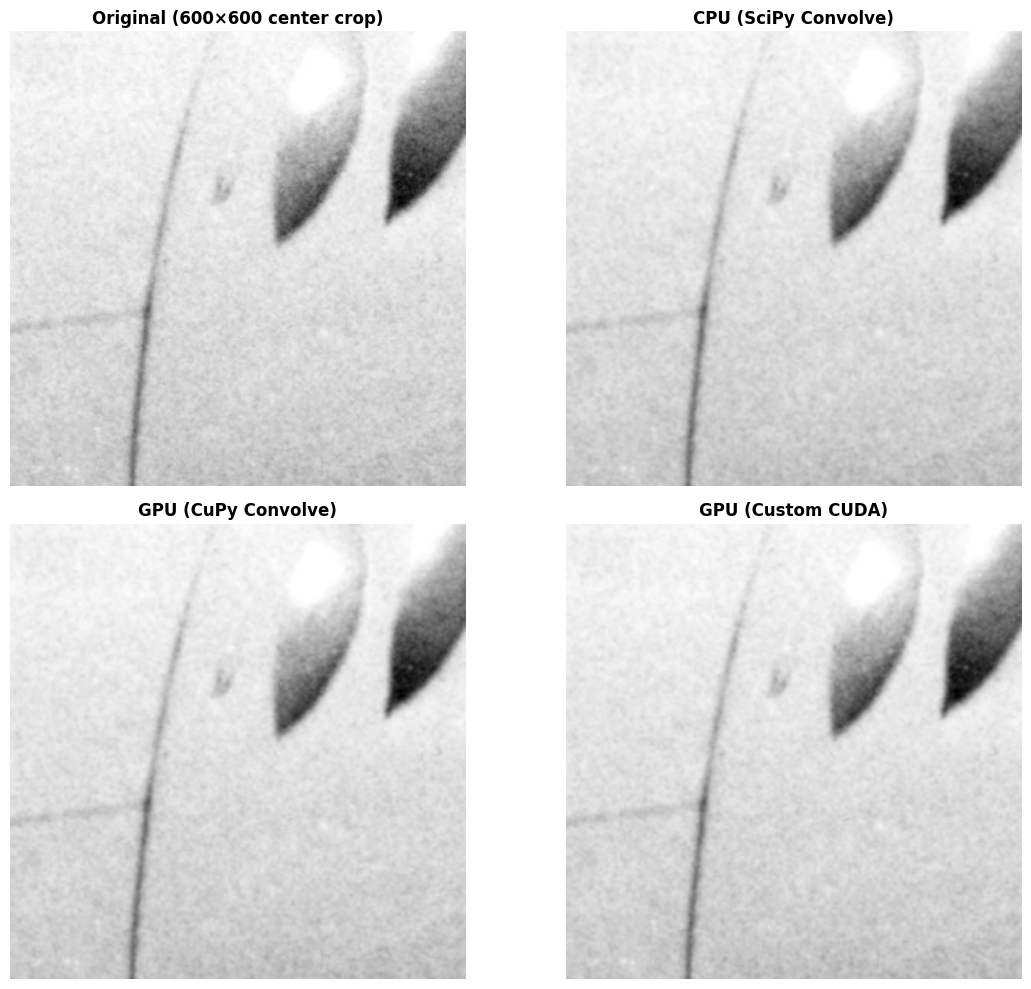

In [10]:
# Visualize a manageable region (center 600x600 pixels)
# This prevents huge plots and slow rendering!
center_h, center_w = img_array.shape[0] // 2, img_array.shape[1] // 2
crop_size = 300  # Show 600x600 region
crop_slice = (slice(center_h - crop_size, center_h + crop_size),
              slice(center_w - crop_size, center_w + crop_size))

fig, axes = plt.subplots(2, 2, figsize=(12, 10))

# Original (cropped)
axes[0, 0].imshow(img_array[crop_slice], cmap='gray')
axes[0, 0].set_title('Original (600×600 center crop)', fontsize=12, fontweight='bold')
axes[0, 0].axis('off')

# CPU result
axes[0, 1].imshow(blurred_cpu[crop_slice], cmap='gray')
axes[0, 1].set_title('CPU (SciPy Convolve)', fontsize=12, fontweight='bold')
axes[0, 1].axis('off')

# CuPy result
axes[1, 0].imshow(blurred_cupy[crop_slice], cmap='gray')
axes[1, 0].set_title('GPU (CuPy Convolve)', fontsize=12, fontweight='bold')
axes[1, 0].axis('off')

# Custom CUDA result
if blurred_cuda is not None:
    axes[1, 1].imshow(blurred_cuda[crop_slice], cmap='gray')
    axes[1, 1].set_title('GPU (Custom CUDA)', fontsize=12, fontweight='bold')
    axes[1, 1].axis('off')
else:
    axes[1, 1].text(0.5, 0.5, 'CUDA Not Available',
                     ha='center', va='center', fontsize=14)
    axes[1, 1].axis('off')

plt.tight_layout()
plt.show()


---
## GPU Monitoring

Understanding GPU utilization, memory usage, and bottlenecks.

In [11]:
def monitor_gpu():
    """
    Display GPU information and current utilization.
    Essential for understanding GPU resource usage.
    """
    print("="*70)
    print("GPU MONITORING")
    print("="*70)

    # Device information
    if CUDA_AVAILABLE:
        device = cuda.get_current_device()
        print(f"\nDevice: {device.name.decode()}")

        # Memory information
        meminfo = cuda.current_context().get_memory_info()
        free_mem = meminfo[0] / 1e9  # Convert to GB
        total_mem = meminfo[1] / 1e9
        used_mem = total_mem - free_mem

        print(f"\nMemory:")
        print(f"   Total:     {total_mem:.2f} GB")
        print(f"   Used:      {used_mem:.2f} GB ({used_mem/total_mem*100:.1f}%)")
        print(f"   Free:      {free_mem:.2f} GB ({free_mem/total_mem*100:.1f}%)")

        # Compute capability
        compute_capability = device.compute_capability
        print(f"\nCompute Capability: {compute_capability[0]}.{compute_capability[1]}")
        print(f"   Max threads per block: {device.MAX_THREADS_PER_BLOCK}")
        print(f"   Max block dimensions: {device.MAX_BLOCK_DIM_X} x {device.MAX_BLOCK_DIM_Y} x {device.MAX_BLOCK_DIM_Z}")
        print(f"   Max grid dimensions: {device.MAX_GRID_DIM_X} x {device.MAX_GRID_DIM_Y} x {device.MAX_GRID_DIM_Z}")

        # CuPy memory pool info
        mempool = cp.get_default_memory_pool()
        print(f"\nCuPy Memory Pool:")
        print(f"   Used bytes: {mempool.used_bytes() / 1e6:.2f} MB")
        print(f"   Total bytes: {mempool.total_bytes() / 1e6:.2f} MB")
    else:
        print("\n❌ No GPU available")

    print("="*70)

monitor_gpu()

GPU MONITORING

Device: Tesla T4

Memory:
   Total:     15.64 GB
   Used:      1.76 GB (11.2%)
   Free:      13.88 GB (88.8%)

Compute Capability: 7.5
   Max threads per block: 1024
   Max block dimensions: 1024 x 1024 x 64
   Max grid dimensions: 2147483647 x 65535 x 65535

CuPy Memory Pool:
   Used bytes: 0.00 MB
   Total bytes: 818.35 MB


---
## Memory Management Deep Dive

Understanding data transfer costs - one of the most common GPU bottlenecks!

In [12]:
def analyze_memory_transfers():
    """
    Break down GPU operation into:
    1. CPU → GPU transfer
    2. GPU computation
    3. GPU → CPU transfer

    This reveals the hidden cost of data movement!
    """
    print("\n" + "="*70)
    print("MEMORY TRANSFER ANALYSIS")
    print("="*70)
    print(f"\nImage size: {img_array.shape} = {img_array.nbytes / 1e6:.2f} MB")

    # Test with CuPy
    print("\nCuPy Implementation:")

    # 1. Transfer to GPU
    start = time.time()
    gpu_image = cp.asarray(img_array)
    transfer_to_gpu = time.time() - start
    print(f"   1️⃣  CPU → GPU transfer: {transfer_to_gpu:.4f}s")

    # 2. GPU computation
    start = time.time()
    blurred_gpu = cp_ndimage.gaussian_filter(gpu_image, sigma=1)
    computation_time = time.time() - start
    print(f"   2️⃣  GPU computation:    {computation_time:.4f}s")

    # 3. Transfer back to CPU
    start = time.time()
    result_cpu = cp.asnumpy(blurred_gpu)
    transfer_to_cpu = time.time() - start
    print(f"   3️⃣  GPU → CPU transfer: {transfer_to_cpu:.4f}s")

    total_time = transfer_to_gpu + computation_time + transfer_to_cpu
    print(f"\n   Total time:         {total_time:.4f}s")
    print(f"\n   Time breakdown:")
    print(f"      Transfers: {(transfer_to_gpu + transfer_to_cpu)/total_time*100:.1f}%")
    print(f"      Compute:   {computation_time/total_time*100:.1f}%")

    # Key insight
    if (transfer_to_gpu + transfer_to_cpu) > computation_time:
        print(f"\n   BOTTLENECK: Memory transfer > computation!")
        print(f"      Solution: Process multiple images in batch, keep data on GPU")
    else:
        print(f"\n   Computation dominates - good candidate for GPU!")

    print("="*70)

analyze_memory_transfers()


MEMORY TRANSFER ANALYSIS

Image size: (8992, 11375) = 409.14 MB

CuPy Implementation:
   1️⃣  CPU → GPU transfer: 0.1988s
   2️⃣  GPU computation:    0.0619s
   3️⃣  GPU → CPU transfer: 0.4017s

   Total time:         0.6624s

   Time breakdown:
      Transfers: 90.7%
      Compute:   9.3%

   BOTTLENECK: Memory transfer > computation!
      Solution: Process multiple images in batch, keep data on GPU


---
## Profiling GPU Code

Use CUDA profiling tools to find bottlenecks.

In [13]:
def profile_custom_kernel():
    """
    Profile custom CUDA kernel to understand performance.
    Shows kernel execution time, memory bandwidth, occupancy.
    """
    print("\n" + "="*70)
    print("PROFILING CUSTOM CUDA KERNEL")
    print("="*70)

    test_img = img_array[:1000, :1000].astype(np.float32)

    # Profile memory bandwidth
    image_size_mb = test_img.nbytes / 1e6
    kernel_size_bytes = kernel.nbytes

    print(f"\nData Characteristics:")
    print(f"   Image size: {test_img.shape[0]}x{test_img.shape[1]}")
    print(f"   Image memory: {image_size_mb:.2f} MB")
    print(f"   Kernel size: {kernel.shape[0]}x{kernel.shape[1]}")
    print(f"   Total pixels: {test_img.size:,}")

    # Execute and time
    print("\nKernel Execution:")
    start = time.time()
    result = blur_cuda_kernel(test_img, kernel)
    cuda.synchronize()
    execution_time = time.time() - start
    print(f"   Time: {execution_time:.4f}s")

    # Calculate metrics
    pixels_per_second = test_img.size / execution_time
    memory_bandwidth = (image_size_mb * 2) / execution_time  # Read + write

    print(f"\nPerformance Metrics:")
    print(f"   Throughput: {pixels_per_second/1e6:.2f} million pixels/sec")
    print(f"   Memory bandwidth: {memory_bandwidth:.2f} MB/s")

    # Thread configuration analysis
    threads_per_block = (16, 16)
    blocks_x = (test_img.shape[0] + 15) // 16
    blocks_y = (test_img.shape[1] + 15) // 16
    total_threads = blocks_x * blocks_y * threads_per_block[0] * threads_per_block[1]

    print(f"\nThread Configuration:")
    print(f"   Threads per block: {threads_per_block[0]}x{threads_per_block[1]} = {threads_per_block[0]*threads_per_block[1]}")
    print(f"   Grid size: {blocks_x}x{blocks_y} blocks")
    print(f"   Total threads launched: {total_threads:,}")
    print(f"   Thread utilization: {test_img.size/total_threads*100:.1f}%")

    print("\nOptimization Opportunities:")
    if memory_bandwidth < 100:
        print("   Low memory bandwidth - memory bound!")
        print("   → Consider using shared memory for kernel weights")
    if test_img.size/total_threads < 0.9:
        print(f"   Only {test_img.size/total_threads*100:.1f}% thread utilization")
        print("   → Many threads do nothing (image size not multiple of block size)")

    print("\nAdvanced Profiling (command line):")
    print("   Use NVIDIA Nsight or nvprof for detailed analysis:")
    print("   $ nvprof python your_script.py")
    print("   $ nsys profile python your_script.py")
    print("="*70)

if CUDA_AVAILABLE:
    profile_custom_kernel()
else:
    print("GPU not available for profiling")


PROFILING CUSTOM CUDA KERNEL

Data Characteristics:
   Image size: 1000x1000
   Image memory: 4.00 MB
   Kernel size: 5x5
   Total pixels: 1,000,000

Kernel Execution:
   Time: 0.0146s

Performance Metrics:
   Throughput: 68.58 million pixels/sec
   Memory bandwidth: 548.66 MB/s

Thread Configuration:
   Threads per block: 16x16 = 256
   Grid size: 63x63 blocks
   Total threads launched: 1,016,064
   Thread utilization: 98.4%

Optimization Opportunities:

Advanced Profiling (command line):
   Use NVIDIA Nsight or nvprof for detailed analysis:
   $ nvprof python your_script.py
   $ nsys profile python your_script.py


---
## Summary

1. **When to Use GPU:**
   - Large data (>1MB)
   - Parallel operations (independent computations)
   - Repeated operations (batch processing)

2. **GPU Structure:**
   - Thread hierarchy (Grid → Blocks → Threads)
   - Memory transfers are expensive
   - Synchronization is critical

3. **Performance Optimization:**
   - Minimize CPU ↔ GPU transfers
   - Keep data on GPU between operations
   - Use batch processing
   - Profile to find bottlenecks

4. **Common Pitfalls:**
   - Using GPU for small data
   - Repeated memory transfers
   - Not synchronizing before timing
   - Not checking GPU memory

### To explore:

- Try other GPU libraries (OpenMP, CUDA C++)
- Explore advanced topics (shared memory, streams, multi-GPU)

